# Laboration 2: Modelling Wine Quality

**Name(s):**
**Date:**

Follow `instructions.md` for the full task description, timing, and the
Checkpoint questions. This notebook is your **working notebook** — light
comments are enough here; your answers to the Checkpoints go on a
**separate answer sheet**, not in this file.

Sections below are labelled to match the instructions exactly
(Step 1 / Step 2 / Step 3 / Step 4) so you can move through the 4-hour
session without hunting for where each part goes.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (mean_squared_error, r2_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score)

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

RANDOM_STATE = 42  # keep this fixed so your results are reproducible

---
## Step 1 — Data Curation (0:00–0:30)

- [ ] Load the data, check shape / columns / dtypes
- [ ] Check for missing values
- [ ] Check for duplicate rows — look closely before deciding what to do (→ **Checkpoint 1a**)
- [ ] Look at the distribution of `quality` (→ **Checkpoint 1b**)
- [ ] Standardise the 11 predictor variables, ready for Step 2

In [35]:
# Load the data (red wine is the primary dataset for Steps 1-3)

# Download the files from github if you are working on uppmax/colab
!wget https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-red.csv
!wget https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-white.csv

df = pd.read_csv('winequality-red.csv', sep=';')
df.head()

--2026-09-18 07:44:30--  https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-red.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84199 (82K) [text/plain]
Saving to: ‘winequality-red.csv.1’

winequality-red.csv 100%[===================>]  82.23K  --.-KB/s    in 0.001s  

2026-09-18 07:44:30 (53.9 MB/s) - ‘winequality-red.csv.1’ saved [84199/84199]

--2026-09-18 07:44:31--  https://raw.githubusercontent.com/peterbmob/1kb570_2026/refs/heads/main/Labs/02_modelling_wine_quality/winequality-white.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [36]:
# TODO: check the shape, column names, and dtypes
print("Shape:", df.shape)

print("\nInfo:")
df.info()

Shape: (1599, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [37]:
# TODO: check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [38]:
# TODO: check for duplicate rows (df.duplicated())
# How many are there? What will you do about them, and why?
# -- write your reasoning on the answer sheet (Checkpoint 1a), not here
num_duplicates = df.duplicated().sum()
print(f"Antal duplicerade rader: {num_duplicates}")

df_clean = df.drop_duplicates()
print("Ny shape efter att dubletter tagits bort:", df_clean.shape)

Antal duplicerade rader: 240
Ny shape efter att dubletter tagits bort: (1359, 12)


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


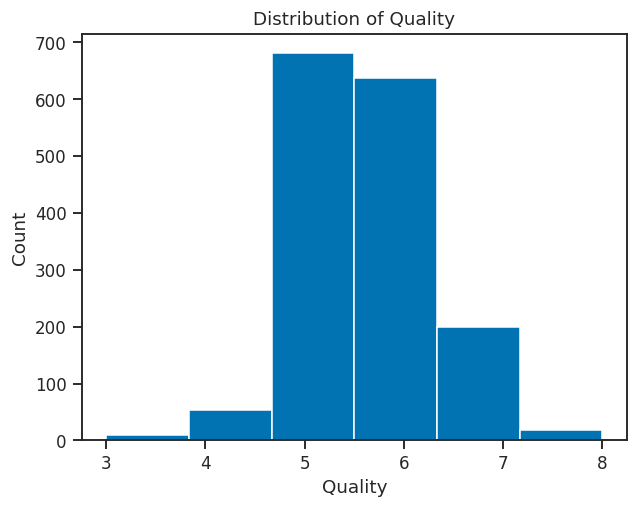

In [39]:
# TODO: look at the distribution of `quality`
# (value_counts() and/or a histogram are both fine)
print(df['quality'].value_counts().sort_index())

df['quality'].hist(bins=6, grid=False)

plt.xlabel('Quality')
plt.ylabel('Count')
plt.title('Distribution of Quality')
plt.show()

In [40]:
# TODO: separate predictors (X, the 11 physicochemical columns) from the
# response (y = quality), then standardise X ready for PCA.
# Hint: StandardScaler().fit_transform(X) -- do NOT standardise quality itself.
X = df.drop('quality', axis=1)
y = df['quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


---
## Step 2 — PCA (0:30–1:30)

Fit PCA on the **standardised predictors only** — `quality` is the response
you are trying to predict, not a predictor, so it must not go into the PCA.

- [ ] Fit PCA, produce a scree plot (individual + cumulative variance)
- [ ] Decide how many components to keep, and by which criterion (→ **Checkpoint 2a**)
- [ ] Score plot (PC1 vs PC2), coloured by `quality` (→ **Checkpoint 2b**)
- [ ] Loading plot for the same two components (→ **Checkpoint 2c**)

In [41]:
# TODO: fit PCA on the standardised predictor matrix
pca = PCA()
scores = pca.fit_transform(X_scaled)

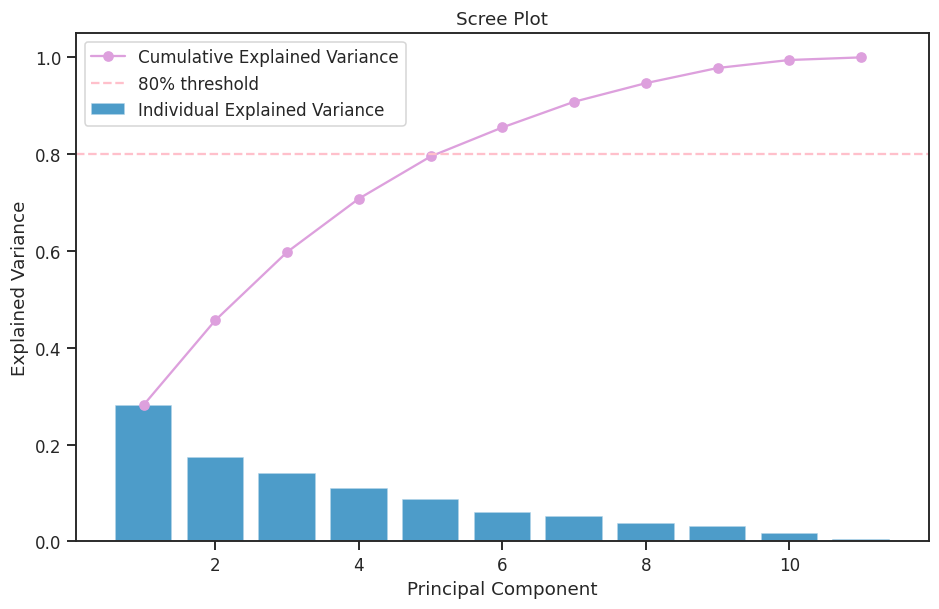

In [56]:
# TODO: scree plot -- individual explained variance (bars) and
# cumulative explained variance (line), same style as the course notebooks
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, align='center', label='Individual Explained Variance')
plt.plot(range(1, len(cumulative_variance) +1), cumulative_variance, color='plum', linestyle='-', marker='o', label='Cumulative Explained Variance')
plt.axhline(y=0.8, color='pink', linestyle='--', label='80% threshold')

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.title('Scree Plot')
plt.legend()
plt.grid(False)
plt.show()


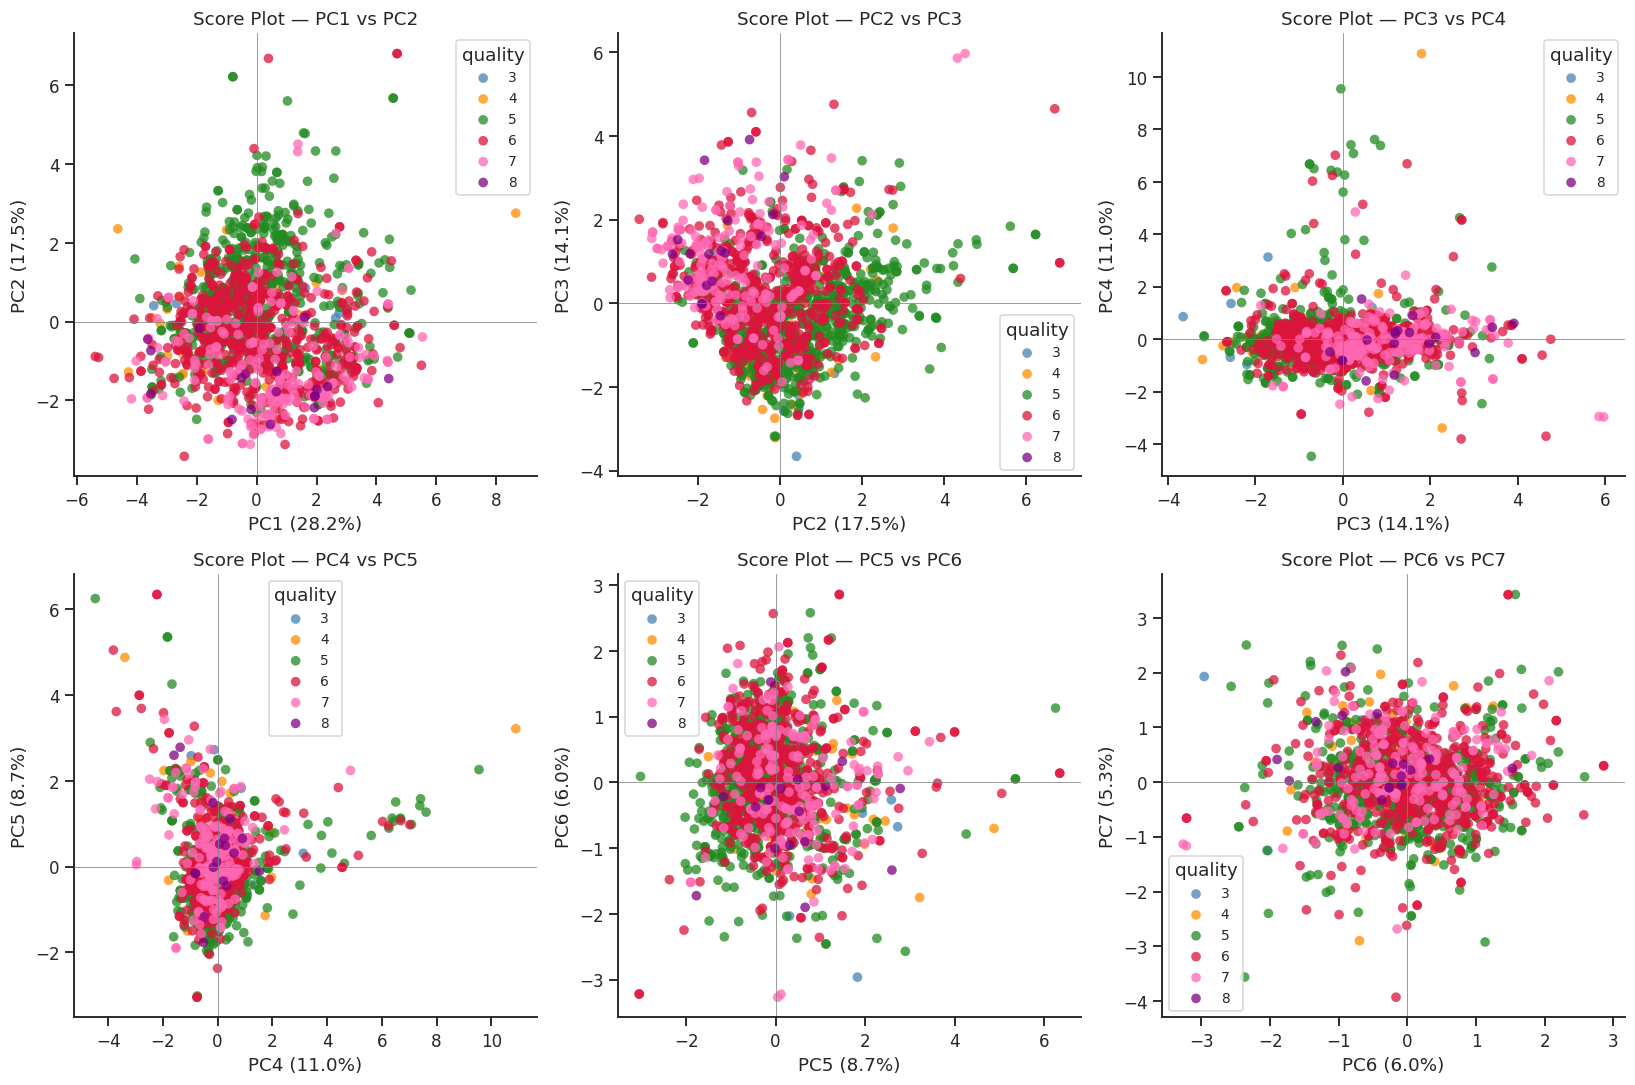

In [79]:
# TODO: score plot -- PC1 vs PC2, colour the points by `quality`
# (a continuous colourmap, e.g. cmap='viridis', works well for an ordinal 0-10 score)
qualities = df['quality'].values
quality_list = [3, 4, 5, 6, 7, 8]
colors_map = dict(zip(quality_list, ['steelblue','darkorange','forestgreen','crimson', 'hotpink', 'purple']))
point_colors = [colors_map[g] for g in qualities]


fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# PC1 vs PC2
for i in range(3):
  ax = axes[0, i]
  for quality, color in colors_map.items():
      mask = qualities == quality
      ax.scatter(scores[mask, i], scores[mask, i+1], c=color,
                 label=quality, s=40, alpha=0.75, edgecolors='none')
  ax.set_xlabel(f'PC{i+1} ({explained_variance[i]*100:.1f}%)')
  ax.set_ylabel(f'PC{i+2} ({explained_variance[i+1]*100:.1f}%)')
  ax.set_title(f'Score Plot — PC{i+1} vs PC{i+2}')
  ax.legend(title='quality', fontsize=9)
  ax.axhline(0, color='gray', lw=0.5)
  ax.axvline(0, color='gray', lw=0.5)
  sns.despine(ax=ax)
  i = +1

# PC1 vs PC2
for i in range(3,6):
  ax = axes[1, i-3]
  for quality, color in colors_map.items():
      mask = qualities == quality
      ax.scatter(scores[mask, i], scores[mask, i+1], c=color,
                 label=quality, s=40, alpha=0.75, edgecolors='none')
  ax.set_xlabel(f'PC{i+1} ({explained_variance[i]*100:.1f}%)')
  ax.set_ylabel(f'PC{i+2} ({explained_variance[i+1]*100:.1f}%)')
  ax.set_title(f'Score Plot — PC{i+1} vs PC{i+2}')
  ax.legend(title='quality', fontsize=9)
  ax.axhline(0, color='gray', lw=0.5)
  ax.axvline(0, color='gray', lw=0.5)
  sns.despine(ax=ax)
  i = +1

fig.tight_layout()
plt.show()



Text(0.5, 1.0, 'Loading Plot')

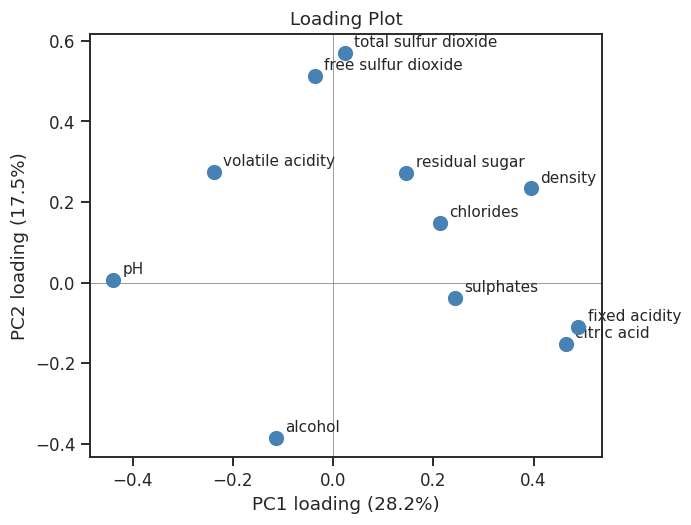

In [84]:
# TODO: loading plot for PC1 vs PC2 -- which variables have the largest
# loadings, and in which direction?
parameters = df.columns[:-1]
loadings = pca.components_.T   # shape (n_variables, n_components)

# Loading plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(loadings[:, 0], loadings[:, 1], color='steelblue', s=80, zorder=5)
for i, elem in enumerate(parameters):
    ax.annotate(elem, (loadings[i, 0], loadings[i, 1]),
                textcoords='offset points', xytext=(6, 4), fontsize=10)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel(f'PC1 loading ({explained_variance[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 loading ({explained_variance[1]*100:.1f}%)')
ax.set_title('Loading Plot')


---
## Step 3 — Model Quality: PLS *and* LDA (1:30–3:00)

Build **both** models today (see `instructions.md` for the full reasoning) —
not a choice between them. Keep both sections; do not delete either.

- [ ] Fit both models with a proper train/test split (or CV)
- [ ] Report validated performance for each, not training-set fit (→ **Checkpoints 3a, 3b**)
- [ ] Compare the two models (→ **Checkpoint 3c**)
- [ ] Identify which variable(s) matter most to each model (→ **Checkpoint 3d**)

### PLS (quality treated as continuous)

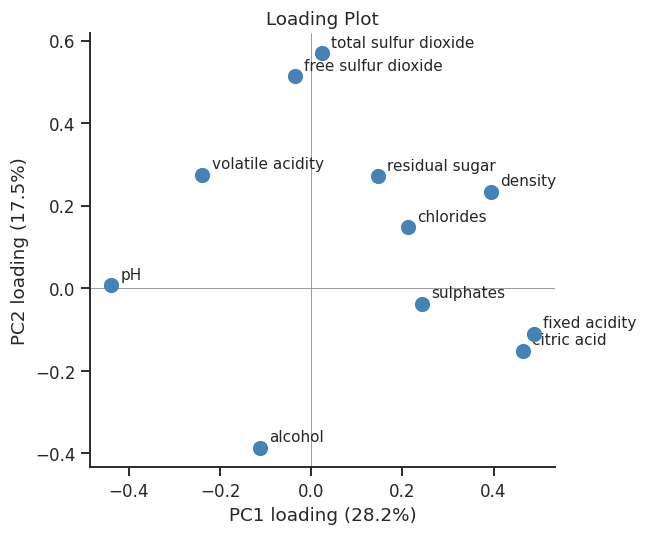

In [81]:
# TODO: train/test split (or set up cross-validation)


In [ ]:
# TODO: fit PLSRegression; choose the number of latent variables using
# cross-validated RMSE or Q^2, not the training-set fit alone

In [ ]:
# TODO: report test-set RMSE and/or R^2, and a predicted-vs-observed plot
# (include the y=x identity line for reference)

### LDA (quality binned into categories)

In [ ]:
# TODO: define your quality bins explicitly here (e.g. low / medium / high).
# State your bin edges and reasoning on the answer sheet (Checkpoint 3b) --
# this is a real modelling decision, not a formality.
# Check the resulting class sizes: are they balanced?

In [ ]:
# TODO: train/test split, then fit LinearDiscriminantAnalysis

In [ ]:
# TODO: report a confusion matrix (ConfusionMatrixDisplay) and per-class
# accuracy on the TEST set -- accuracy alone is not enough here

In [ ]:
# TODO: Checkpoint 3c/3d groundwork -- pull out and compare the top
# variables from both models (PLS coefficients vs. LDA discriminant
# loadings). Your written comparison goes on the answer sheet.

---
## Step 4 — Does It Transfer? White Wine (3:00–3:45)

Repeat the analysis on `winequality-white.csv` and check whether your
Step 2/3 findings are genuine wine chemistry or specific to the red-wine
dataset. You only need to redo **one** of PLS/LDA here, not both.

- [ ] Curate the white wine data the same way as Step 1 (its own duplicate/quality-distribution answer will differ from red)
- [ ] Redo the PCA from Step 2 on white wine (→ **Checkpoint 4a**)
- [ ] Redo ONE of your two Step 3 models on white wine (→ **Checkpoint 4b**)

In [ ]:
# TODO: load winequality-white.csv, curate it the same way as Step 1
# (missing values, duplicates, quality distribution)

In [ ]:
# TODO: standardise the white-wine predictors and redo the PCA + scree/
# score/loading plots from Step 2. Compare PC1's top-loading variables to
# what you found for red wine (Checkpoint 2c) -- write the comparison on
# the answer sheet (Checkpoint 4a).

In [ ]:
# TODO: redo ONE of your two Step 3 models (PLS or LDA -- your choice) on
# white wine, same methodology as before. Compare validated performance and
# top variables to your red-wine result (Checkpoint 3a/3b/3d) -- write the
# comparison on the answer sheet (Checkpoint 4b).

---
## Wrap-up (3:45–4:00)

- [ ] Finalise your answer sheet (Checkpoints 1a–4b)

Hand in **this notebook** + your **answer sheet** — no separate report.